In [2]:
import numpy as np
import torch
from os.path import join
import pandas as pd

In [8]:
data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'
data = np.load(join(data_path, 'data_no_scale.npz'))
gene_sc = torch.tensor(data['arr_0'], dtype=torch.float32, device='cuda:0').squeeze(0)
gene_st = torch.tensor(data['arr_1'], dtype=torch.float32, device='cuda:0').squeeze(0)
# gene_sc = torch.tensor(gene_sc, dtype=torch.float32, device='cuda:0')
# gene_st = torch.tensor(gene_st, dtype=torch.float32, device='cuda:0')

In [10]:
print(gene_sc.shape)
print(gene_st.shape)

torch.Size([1289, 6025])
torch.Size([3366, 6025])


In [11]:
# import sim_tangram.train_tangram as tg_cca
# # tangram
# cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
#     [gene_sc[10:50]],
#     [gene_st[10:50]],
#     num_epochs=500,
#     print_interval=1,
#     lambda_g1=1,
#     lambda_g2=1,
# )

**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:04<00:00, 110.27it/s]


Epoch 500: Loss -1.3456993103027344
[[-1.2038578  -0.53854215 -0.80877554 ...  0.57604176 -2.3016665
  -2.873697  ]
 [-0.81793416 -0.4041274  -1.6820776  ...  0.9965971  -3.0244377
  -3.4719045 ]
 [-0.06655915  1.0659386  -0.8569197  ... -0.36091894 -2.3997452
  -2.6211362 ]
 ...
 [ 8.895682    0.04835094 -0.8781819  ...  0.47362056 -3.2257767
  -2.474183  ]
 [ 0.5030791   9.142751    1.2816347  ...  0.57589096 -2.4119513
  -2.9899802 ]
 [ 8.594484   -0.80002224  8.623271   ... -0.01416233 -3.4019194
  -2.7757573 ]]


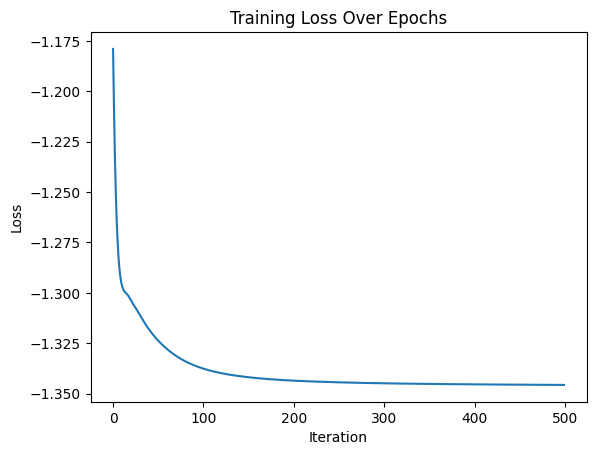

In [15]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc],
    [gene_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [14]:
# sim2 = cos_sim_tg.copy()
# prob = np.exp(sim2) / np.sum(np.exp(sim2), axis=1, keepdims=True)
# maxprob = prob.max(axis=1)
# mask = maxprob < 0.0009
# first_hot = np.zeros_like(sim2[0])
# first_hot[0] = 1
# sim2[mask] = first_hot
# # print(maxprob.min())
# # print(maxprob.max())

In [16]:
torch.save(torch.tensor(cos_sim_tg, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg_no_scale.pt')
# torch.save(torch.tensor(sim2, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg2.pt')

# torch.save(torch.tensor(cca_tg_sim, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cca_tg.pt')

In [17]:
np.argmax(cos_sim_tg, axis=1)

array([1653, 1110,  468, ..., 1386, 1195, 1395])

In [7]:
# 对每一行应用softmax转换为概率分布
# tg = torch.tensor(cos_sim_tg, dtype=torch.float32)
# tg_norm = tg / tg.sum(dim=1, keepdim=True)